# 02. HCC本丸: core fucose / bisecting / branching を動かす承認薬（HepG2）

**狙い**（`/paper-value` 出口①検出・②感作）：HCCの糖鎖標的の中核
- **Core fucose (FUT8)** = AFP-L3 の実体、AAL/LCAレクチンで検出 → wet validation第一候補
- **Bisecting GlcNAc (MGAT3, GnT-III)** = E4-PHA
- **β1,6分岐 (MGAT5, GnT-V)** = L-PHA

これらを **HepG2（HCC細胞）で増やす/減らす承認薬** を、epitope potential のコントラストで順位付けする。
単一遺伝子エピトープなので potential = その遺伝子の z（step内max×step間minの縮退）。

辞書: `RAW.GLYCOEPITOPE`（MAN0001-3 手動キュレーション）／注釈: 2nd paper compound master。

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import snowflake.connector as sc

con = sc.connect(account='DUETMBM-LL33279', user='KOREEDA', role='ACCOUNTADMIN',
    warehouse='BIOINFORMATICS_XS', authenticator='SNOWFLAKE_JWT',
    private_key_file=os.path.expanduser('~/.ssh/snowflake_rsa_key.pem'))
cur = con.cursor()
CELL='HEPG2'
GENES={'Core fucose (FUT8/AFP-L3)':'FUT8','Bisecting GlcNAc (MGAT3)':'MGAT3','beta1,6-branching (MGAT5)':'MGAT5'}
print('connected')

connected


## 1. HepG2でFUT8/MGAT3/MGAT5の発現を取得→化合物平均→コントラスト(中心化)

In [2]:
sel=', '.join(['"pertname"']+[f'"{g}"' for g in GENES.values()])
df=cur.execute(f'SELECT {sel} FROM RAW.LINCS.GLYCO_GENES_WIDE WHERE "cell"=%s',(CELL,)).fetch_pandas_all()
df.columns=['pertname']+list(GENES.values())
for g in GENES.values(): df[g]=pd.to_numeric(df[g],errors='coerce')
cmean=df.groupby('pertname')[list(GENES.values())].mean()
# コントラスト: 全化合物平均を基準線に中心化 → 化合物間z
cont=cmean-cmean.mean(0)
z=(cont-cont.mean(0))/cont.std(0)
print(f'{CELL}: {cmean.shape[0]}化合物 × {cmean.shape[1]}遺伝子')
print(cmean.describe().round(3).T[['mean','std','min','max']])

HEPG2: 4704化合物 × 3遺伝子
       mean    std    min    max
FUT8   -0.0  0.007 -0.026  0.032
MGAT3  -0.0  0.008 -0.031  0.030
MGAT5   0.0  0.007 -0.025  0.027


## 2. 承認薬アノテーション結合（BRD→実薬名・ATC・MoA）

In [3]:
MASTER='/Users/koreedatatsuya/research/lincs_glyco_2nd_paper/inputs/moa_target_master/compound_annotation_master.csv'
ann=pd.read_csv(MASTER).set_index('compound_id'); ann=ann[~ann.index.duplicated()]
approved=ann[ann['MAX_PHASE']>=4]
ap=[c for c in cont.index if c in approved.index]
print(f'承認薬 {len(ap)} 化合物')
cont_ap=cont.loc[ap]; z_ap=(cont_ap-cont_ap.mean(0))/cont_ap.std(0)

承認薬 456 化合物


## 3. core fucose (FUT8/AFP-L3) を増やす承認薬 = wet validation第一候補

AAL/LCAレクチン染色で検証できる。増やす薬・減らす薬の両方を出す。

In [4]:
def rank_drugs(gene, n=12):
    s=cont_ap[gene].dropna().sort_values(ascending=False)
    def tab(idx):
        t=approved.loc[idx,['PREF_NAME','ATC_L1_desc','MOA']].copy()
        t.insert(0,'z',z_ap[gene][idx].round(2)); t.insert(1,'potential',cont_ap[gene][idx].round(3))
        return t.reset_index(drop=True)
    return tab(s.head(n).index), tab(s.tail(n).index)

up,dn=rank_drugs('FUT8')
print('▲ core fucose を増やす承認薬 top12（AAL/LCAで↑を検証）'); print(up.to_string())
print('\n▼ core fucose を減らす承認薬 top12'); print(dn.to_string())

▲ core fucose を増やす承認薬 top12（AAL/LCAで↑を検証）
       z  potential              PREF_NAME                                 ATC_L1_desc                                                                                                                  MOA
0   4.40      0.032              MILRINONE                       CARDIOVASCULAR SYSTEM                                                                                                                  NaN
1   2.81      0.021          AMITRIPTYLINE                              NERVOUS SYSTEM                                                                                                                  NaN
2   2.55      0.019              VALSARTAN                       CARDIOVASCULAR SYSTEM                                                                            Type-1 angiotensin II receptor antagonist
3   2.44      0.018            TOFACITINIB  ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS                                                        

## 4. bisecting (MGAT3) / branching (MGAT5) を動かす承認薬

In [5]:
for g,lab in [('MGAT3','Bisecting GlcNAc (MGAT3, E4-PHA)'),('MGAT5','beta1,6-branching (MGAT5, L-PHA)')]:
    up,_=rank_drugs(g,8)
    print(f'\n▲ {lab} を増やす承認薬 top8'); print(up[['z','PREF_NAME','ATC_L1_desc','MOA']].to_string())


▲ Bisecting GlcNAc (MGAT3, E4-PHA) を増やす承認薬 top8
      z      PREF_NAME                                          ATC_L1_desc                                                   MOA
0  3.32      NAFTIFINE                                      DERMATOLOGICALS                                                   NaN
1  2.66  DICLOXACILLIN                      ANTIINFECTIVES FOR SYSTEMIC USE                                                   NaN
2  2.65       DOXAPRAM                                   RESPIRATORY SYSTEM                                                   NaN
3  2.54    PROPRANOLOL                                CARDIOVASCULAR SYSTEM                                                   NaN
4  2.52     FLUOXETINE                                       NERVOUS SYSTEM                                                   NaN
5  2.46      PROGUANIL  ANTIPARASITIC PRODUCTS, INSECTICIDES AND REPELLENTS                                                   NaN
6  2.38    BENZONATATE                   

## 5. 図: core fucose を増やす/減らす承認薬 top15

/var/folders/yb/qg8q9dxs50jft5_qv15b_2700000gn/T/ipykernel_36572/3993397784.py:10: UserWarning: Glyph 12434 (\N{HIRAGANA LETTER WO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yb/qg8q9dxs50jft5_qv15b_2700000gn/T/ipykernel_36572/3993397784.py:10: UserWarning: Glyph 21205 (\N{CJK UNIFIED IDEOGRAPH-52D5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yb/qg8q9dxs50jft5_qv15b_2700000gn/T/ipykernel_36572/3993397784.py:10: UserWarning: Glyph 12363 (\N{HIRAGANA LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yb/qg8q9dxs50jft5_qv15b_2700000gn/T/ipykernel_36572/3993397784.py:10: UserWarning: Glyph 12377 (\N{HIRAGANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yb/qg8q9dxs50jft5_qv15b_2700000gn/T/ipykernel_36572/3993397784.py:10: UserWarning: Glyph 25215 (\N{CJK UNIFIED IDEOGRAPH-627F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yb/qg8q9dxs50jft5_qv15b_2700000

/Users/koreedatatsuya/miniconda3/envs/glyco_pred/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12434 (\N{HIRAGANA LETTER WO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/koreedatatsuya/miniconda3/envs/glyco_pred/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21205 (\N{CJK UNIFIED IDEOGRAPH-52D5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/koreedatatsuya/miniconda3/envs/glyco_pred/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12363 (\N{HIRAGANA LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/koreedatatsuya/miniconda3/envs/glyco_pred/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12377 (\N{HIRAGANA LETTER SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/koreedatatsuya/miniconda3/envs/glyco_pred

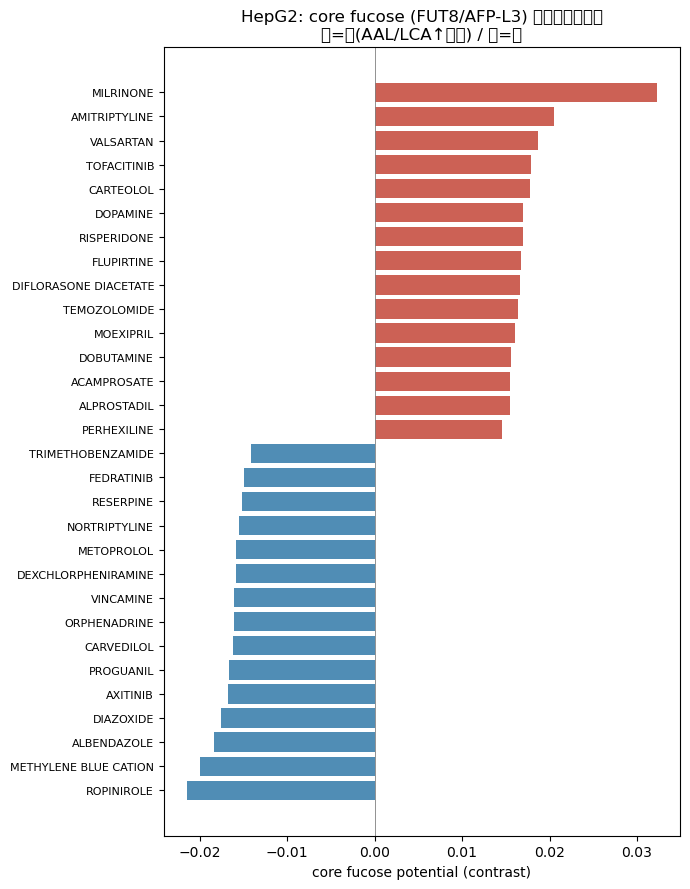

saved hcc_core_fucose_approved.png


In [6]:
s=cont_ap['FUT8'].dropna().sort_values()
sel=pd.concat([s.head(15),s.tail(15)])
names=[approved.loc[i,'PREF_NAME'] if pd.notna(approved.loc[i,'PREF_NAME']) else i for i in sel.index]
colors=['#2471a3' if v<0 else '#c0392b' for v in sel.values]
fig,ax=plt.subplots(figsize=(7,9))
ax.barh(range(len(sel)),sel.values,color=colors,alpha=0.8)
ax.set_yticks(range(len(sel))); ax.set_yticklabels(names,fontsize=8)
ax.axvline(0,color='grey',lw=0.6); ax.set_xlabel('core fucose potential (contrast)')
ax.set_title('HepG2: core fucose (FUT8/AFP-L3) を動かす承認薬\n赤=増(AAL/LCA↑候補) / 青=減')
plt.tight_layout()
os.makedirs('../../results/figures',exist_ok=True)
fig.savefig('../../results/figures/hcc_core_fucose_approved.png',dpi=150,bbox_inches='tight')
plt.show(); print('saved hcc_core_fucose_approved.png')

In [7]:
os.makedirs('../../results/tables',exist_ok=True)
out=cont_ap[list(GENES.values())].copy()
out.columns=[f'{g}_potential' for g in GENES.values()]
out=out.join(approved[['PREF_NAME','ATC_L1_desc','MOA','MAX_PHASE']])
out.to_csv('../../results/tables/hcc_epitope_potential_approved.csv')
print('saved hcc_epitope_potential_approved.csv', out.shape)
con.close()

saved hcc_epitope_potential_approved.csv (456, 7)
